# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Regular linear models are pretty limited since everything has to be a straight line. These extensions let us model more complex relationships while still keeping things somewhat interpretable. Activation functions and link functions add flexibility, so we can handle things like probabilities or nonlinear patterns instead of forcing everything into a linear shape.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Because logistic regression predicts probabilities, and cross entropy directly measures how far those are from the true labels. It also punishes confident wrong answers a lot, which helps the model learn faster and more accurately.

3. True or false, and explain: Logistic regression is a linear model.

True, but kind of misleading. It's linear in the inputs and coefficients, but the final output goes through a sigmoid, so the predictions themselves aren't linear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. That's actually what it's used for. It gives probabilities, and you turn those into classes using a cutoff like 0.5.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. They represent change in log-odds, not probability. The effect on probability depends on where you are on the curve.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Even though there's a nonlinear sigmoid at the end, the model itself is still linear in features. You still need feature engineering to capture more complex patterns.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. It depends on the problem. Logistic regression is for classification, OLS is for continuous outcomes. One isn't just better than the other.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/Humzah-Syed/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 30 (delta 8), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (30/30), 31.69 KiB | 4.53 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Download complete
Extracting data files...
Data extracted


In [3]:
import pandas as pd


df = pd.read_csv("data.csv", sep=";")


cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols]

df = df.dropna()

# create binary target: 1 = Dropout, 0 = Not dropout
df["Dropout"] = (df["Target"] == "Dropout").astype(int)

In [4]:
from sklearn.linear_model import LogisticRegression

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y = df["Dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# coefficients
for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

Debtor 0.5306254196925666
Tuition fees up to date -2.55654243281313
Scholarship holder -1.227441522252298
Age at enrollment 0.04992541246433546


From the regression results, debtor status and age both increase the probability of dropping out, since their coefficients are positive. In contrast, being up to date on tuition and having a scholarship both decrease dropout probability, and the effect of tuition status is especially strong compared to the others. So overall, financial strain seems to push students toward dropping out, while financial stability and support pull them in the opposite direction. Being up to date on tuition clearly reduces dropout risk.

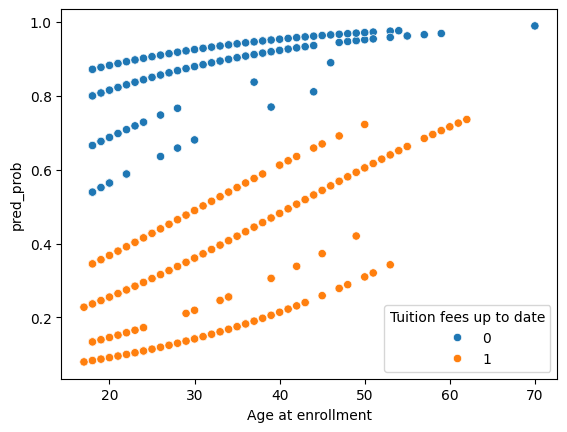

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# predicted probabilities
df["pred_prob"] = model.predict_proba(X)[:, 1]

# scatter plot
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date"
)
plt.show()

Looking at the scatter plot, the difference between students who are and aren’t up to date on tuition is noticeable across all ages, but it becomes slightly more pronounced as age increases. Older students already tend to have higher predicted dropout probabilities, so being up to date on tuition has a bigger impact for them. On average, students who are up to date on tuition have a much lower predicted probability of dropping out, showing that tuition status plays a major role in reducing risk.

In [7]:
avg_diff = df.groupby("Tuition fees up to date")["pred_prob"].mean()
print(avg_diff)

Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

print(confusion_matrix(y, y_pred))
print("Accuracy:", accuracy_score(y, y_pred))

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


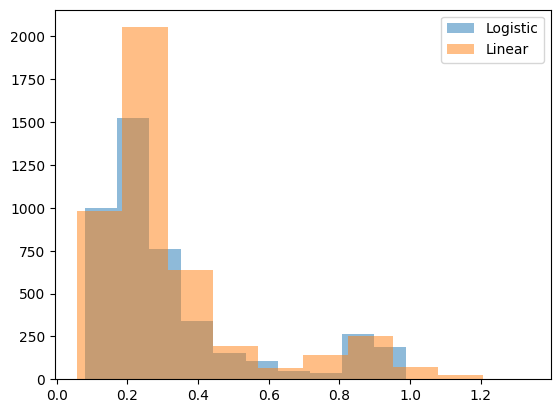

In [9]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_pred"] = lin_model.predict(X)

# histograms
plt.hist(df["pred_prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

On average, being up to date on tuition makes a very large difference in predicted dropout probability. Students who are not up to date have an average predicted dropout probability of about 0.86, while those who are up to date are around 0.25. That's a drop of roughly 0.61, which is huge, and it really reinforces that tuition status is one of the strongest factors in the model.

Looking at the confusion matrix, the model has an accuracy of about 76%, which is solid but not perfect. It does a good job identifying students who don't drop out, but it misses a fair number of actual dropouts, as seen in the false negatives. So while the model is reasonably accurate overall, it's a bit weaker when it comes to catching all the at-risk students.

When comparing logistic regression to the linear model, the difference is pretty clear in the histogram. The logistic model keeps predicted probabilities between 0 and 1, which makes sense, while the linear model produces some values above 1, which aren't valid probabilities. Because of that, logistic regression gives more realistic and interpretable predictions, so it's definitely the better choice here.

In [10]:
from sklearn.linear_model import LogisticRegression

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
multi_model.fit(X_multi, y_multi)

# predictions
y_pred_multi = multi_model.predict(X_multi)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_multi, y_pred_multi))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [13]:
import pandas as pd

df = pd.read_csv("cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]

# drop missing values
df = df.dropna()

# binary target: 1 = alive, 0 = dead
df["Survived"] = df["Status"].isin(["C", "CL"]).astype(int)

# encode categorical variables
df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

I removed rows with missing values to keep the dataset clean and avoid introducing bias from imputation. This keeps the analysis straightforward and ensures the model is trained only on complete observations.

In [14]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Status", "Survived", "Stage"])
y = df["Survived"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

Bilirubin -0.35142389843544086
Edema_S -0.45067663255235757
Edema_Y -1.6110491833168035
Drug_Placebo 0.23122512449170882


The regression results show a few clear patterns. Bilirubin has a negative coefficient, which means higher bilirubin levels are associated with a lower probability of survival, which fits with it being a marker of worse liver function. For edema, both S and Y have negative coefficients, and the effect is much stronger for Y, suggesting that more severe edema corresponds to a significantly lower chance of survival compared to no edema. Looking at the drug variable, the coefficient for placebo is positive, which implies that being on the placebo slightly increases survival compared to the baseline group (which would be the treatment group). This suggests that the drug does not improve survival in this model and may even be associated with slightly worse outcomes, although the effect is relatively small compared to factors like bilirubin and edema.

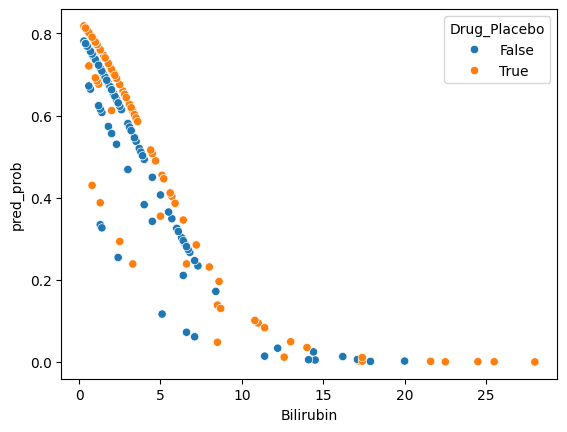

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df["pred_prob"] = model.predict_proba(X)[:, 1]

sns.scatterplot(
    data=df,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_Placebo"
)
plt.show()

In [19]:
df.groupby("Drug_Placebo")["pred_prob"].mean()

,pred_prob
Drug_Placebo,
False,0.590054
True,0.608902


The scatter plot shows a clear downward trend, where survival probability decreases as bilirubin increases, which lines up with the idea that higher bilirubin reflects more severe liver damage. When comparing the two groups, patients on the placebo (True) tend to have slightly higher predicted survival probabilities than those on the drug (False), especially at lower to moderate bilirubin levels. However, as bilirubin gets very high, survival probability drops close to zero for both groups, so the difference between them becomes much smaller.

On average, patients on the placebo have a predicted survival probability of about 0.609, while those on the drug are around 0.590. This means the placebo group actually has a slightly higher predicted survival probability by about 0.019. So based on this model, the drug does not appear to improve survival, and if anything, it is associated with a very small decrease in survival probability, though the effect is pretty minor compared to the impact of bilirubin.

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

print(confusion_matrix(y, y_pred))
print("Accuracy:", accuracy_score(y, y_pred))

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


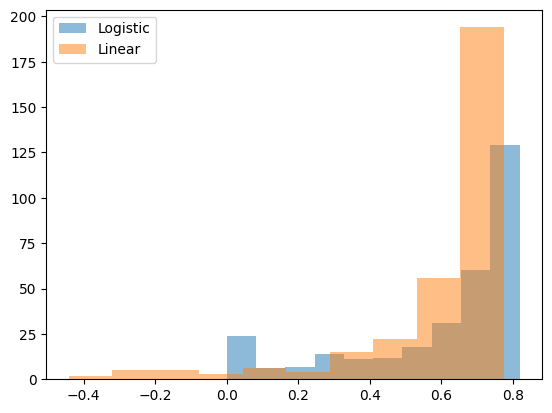

In [21]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_pred"] = lin_model.predict(X)

plt.hist(df["pred_prob"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

In [22]:
X_stage = df[["Bilirubin"] + [col for col in df.columns if "Edema_" in col]]
y_stage = df["Stage"]

stage_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
stage_model.fit(X_stage, y_stage)

y_pred_stage = stage_model.predict(X_stage)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_stage, y_pred_stage))

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [23]:
probs = stage_model.predict_proba(X_stage)
print(probs[:5])

[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

For a linear model:

$$
\hat{y} = b_0 + \sum_{k=1}^{K} b_k x_k
$$

Taking the derivative with respect to feature $x_k$:

$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

A one-unit increase in $x_k$ changes the prediction by:

$$
\Delta \hat{y} = b_k
$$

So the effect of a feature is constant and does not depend on $x$.

For logistic regression:

$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

Let $L = b \cdot x$, then:

$$
\hat{p} = \frac{e^L}{1 + e^L}
$$

The derivative with respect to $L$ is:

$$
\frac{d\hat{p}}{dL} = \hat{p}(1 - \hat{p})
$$

Using the chain rule:

$$
\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1 - \hat{p})
$$

A one-unit increase in $x_k$ changes the prediction by:

$$
\Delta \hat{p} = b_k \cdot \hat{p}(1 - \hat{p})
$$

Unlike the linear model, this effect depends on $\hat{p}$.

Starting from:

$$
\hat{p} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}
$$

We can rewrite:

$$
\hat{p}(1 + e^{b \cdot x}) = e^{b \cdot x}
$$

$$
\hat{p} = (1 - \hat{p}) e^{b \cdot x}
$$

$$
\frac{\hat{p}}{1 - \hat{p}} = e^{b \cdot x}
$$

Taking the log:

$$
\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x
$$

So for a one-unit increase in $x_k$:

$$
\Delta \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b_k
$$

This means:

$$
\text{odds} \rightarrow e^{b_k} \times \text{odds}
$$

So a one-unit increase in $x_k$ multiplies the odds by $e^{b_k}$.